Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load Data

In [2]:
df = pd.read_csv("../data/usgs_2025_clean.csv")

Jumlah Gempa Perbulan

In [3]:
#Menghitung Jumlah Gempa
monthly_eq = df.groupby("month").size()

monthly_eq

month
1     11642
2     11509
3     11865
4     11234
5     10392
6     10602
7     16555
8     12673
9     11338
10     8952
11     9718
12    13448
dtype: int64

Distribusi Magnitude

In [4]:
#Statistik Deskriptif
df["magnitude"].describe()

count    139928.000000
mean          1.699638
std           1.386048
min          -5.000000
25%           0.780000
50%           1.480000
75%           2.200000
max           8.800000
Name: magnitude, dtype: float64

Rangking 20 Gempa Terbesar

In [5]:
top20 = df.nlargest(
    20,
    "magnitude"
)

top20[
    ["time","place","magnitude"]
]

,time,place,magnitude
68998,2025-07-29 23:24:52.483,"2025 Kamchatka Peninsula, Russia Earthquake",8.8
101007,2025-09-18 18:58:14.939,"140 km E of Petropavlovsk-Kamchatsky, Russia",7.8
24456,2025-03-28 06:20:52.715,"2025 Mandalay, Burma (Myanmar) Earthquake",7.7
20114,2025-02-08 23:23:14.697,"210 km SSW of George Town, Cayman Islands",7.6
113457,2025-10-10 20:29:20.075,Drake Passage,7.6
136667,2025-12-08 14:15:09.896,"2025 Aomori Prefecture, Japan Earthquake",7.6
87648,2025-08-22 02:16:18.246,2025 Southern Drake Passage Earthquake,7.5
56126,2025-05-02 12:58:26.014,2025 Drake Passage Earthquake,7.4
74050,2025-07-20 06:49:04.327,"2025 Eastern Kamchatka, Russia Earthquake",7.4
103131,2025-09-13 02:37:56.761,"105 km E of Petropavlovsk-Kamchatsky, Russia",7.4


Melihat Kedalaman Gempa

In [6]:
#Statistik
df["depth"].describe()

count    139928.000000
mean         22.451175
std          54.613422
min          -3.500000
25%           3.390000
50%           7.850000
75%          15.090000
max         669.556000
Name: depth, dtype: float64

Klasifikasi Magnitude

In [7]:
#Membuat Kategori Gempa
def kategori_mag(mag):

    if mag < 3:
        return "Kecil"

    elif mag < 5:
        return "Sedang"

    elif mag < 7:
        return "Besar"

    else:
        return "Sangat Besar"
    
#Menambahkan Kolom Kategori
df["kategori"] = df["magnitude"].apply(
    kategori_mag
)
df["kategori"].value_counts()


kategori
Kecil           117155
Sedang           20647
Besar             2110
Sangat Besar        16
Name: count, dtype: int64

Wilayah dan Negara dengan Gempa Terbanyak

In [8]:
df["place"].head(20)
df["place"].value_counts().head(20)

place
7 km NW of The Geysers, CA               1318
8 km NNW of The Geysers, CA               961
22 km ENE of Ashford, Washington          935
7 km WNW of Cobb, CA                      873
8 km WNW of Cobb, CA                      747
9 km NW of The Geysers, CA                739
6 km WNW of Cobb, CA                      701
8 km NW of Prague, Oklahoma               682
7 km NNW of The Geysers, CA               643
6 km NW of The Geysers, CA                609
8 km NW of The Geysers, CA                590
10 km NW of The Geysers, CA               568
23 km ENE of Ashford, Washington          537
Rat Islands, Aleutian Islands, Alaska     512
6 km NNW of The Geysers, CA               472
55 km S of Whites City, New Mexico        422
65 km WNW of Beluga, Alaska               410
3 km NW of The Geysers, CA                404
56 km S of Whites City, New Mexico        399
66 km WNW of Beluga, Alaska               397
Name: count, dtype: int64

Gempa Perhari

In [9]:
daily_eq = df.groupby("date").size()
daily_eq.head()

date
2025-01-01    436
2025-01-02    579
2025-01-03    386
2025-01-04    348
2025-01-05    345
dtype: int64

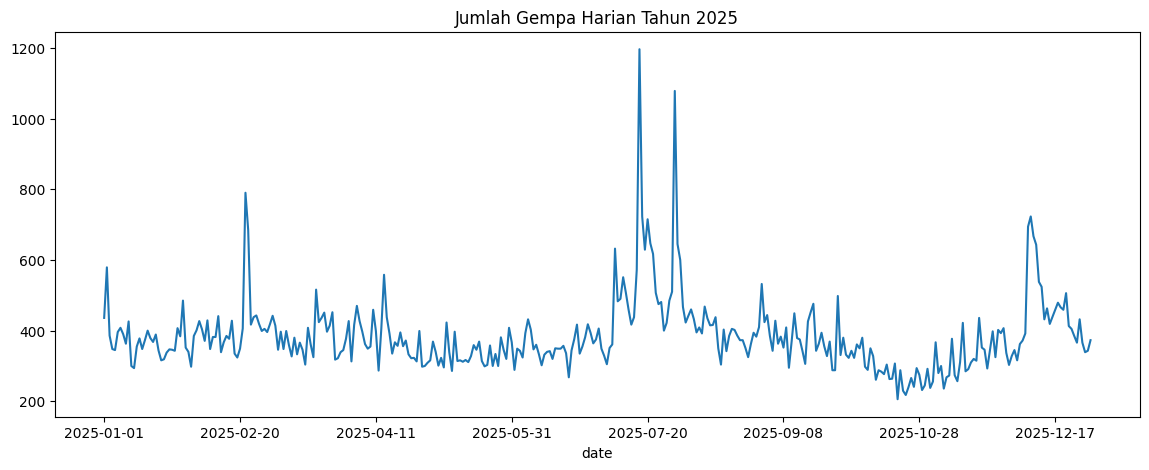

In [10]:
daily_eq.plot(
    figsize=(14,5)
)

plt.title(
    "Jumlah Gempa Harian Tahun 2025"
)

plt.show()

Menyimpan Dataset Final

In [11]:
df.to_csv(
    "../data/usgs_2025_final.csv",
    index=False
)